In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [ ]:
train_data = pd.read_csv("/content/drive/MyDrive/train_aWnotuB.csv")
test_data = pd.read_csv("/content/drive/MyDrive/datasets_8494_11879_test_BdBKkAj.csv")

In [ ]:
train_data.head()

,DateTime,Junction,Vehicles,ID
0,2015-11-01 00:00:00,1,15,20151101001
1,2015-11-01 01:00:00,1,13,20151101011
2,2015-11-01 02:00:00,1,10,20151101021
3,2015-11-01 03:00:00,1,7,20151101031
4,2015-11-01 04:00:00,1,9,20151101041


In [ ]:
train_data.head()

,DateTime,Junction,Vehicles,ID
0,2015-11-01 00:00:00,1,15,20151101001
1,2015-11-01 01:00:00,1,13,20151101011
2,2015-11-01 02:00:00,1,10,20151101021
3,2015-11-01 03:00:00,1,7,20151101031
4,2015-11-01 04:00:00,1,9,20151101041


In [ ]:
train_data.isnull().sum()

,0
DateTime,0
Junction,0
Vehicles,0
ID,0


In [ ]:
test_data.isnull().sum()

,0
DateTime,0
Junction,0
ID,0


In [ ]:
train_data.duplicated().sum()

np.int64(0)

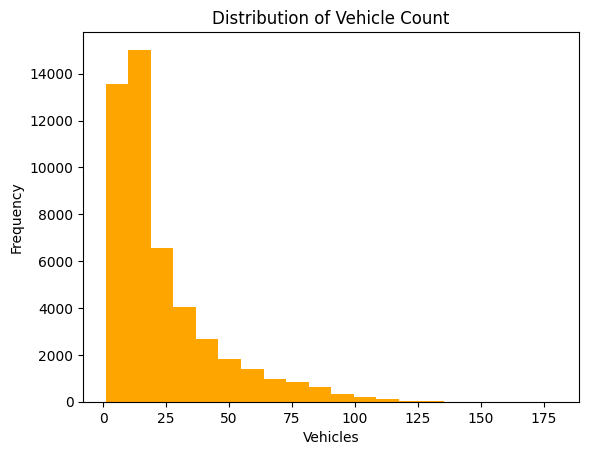

In [ ]:
plt.hist(train_data["Vehicles"], bins=20,color="orange")
plt.xlabel("Vehicles")
plt.ylabel("Frequency")
plt.title("Distribution of Vehicle Count")
plt.show()

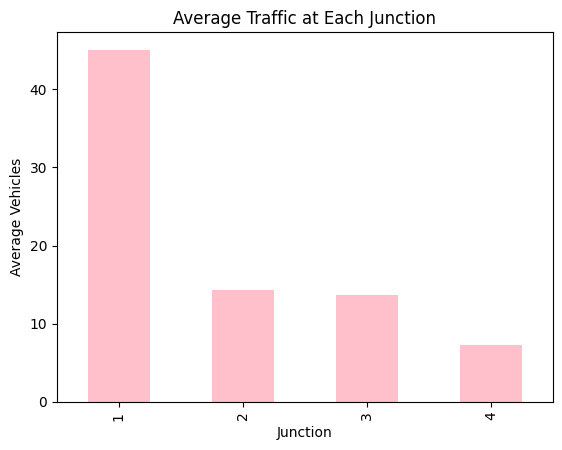

In [ ]:
train_data.groupby("Junction")["Vehicles"].mean().plot(kind="bar",color='pink')
plt.xlabel("Junction")
plt.ylabel("Average Vehicles")
plt.title("Average Traffic at Each Junction")
plt.show()

In [ ]:
test_ids = test_data["ID"]

In [ ]:
train_data.drop("ID", axis=1, inplace=True)

In [ ]:
test_data.drop("ID", axis=1, inplace=True)

In [ ]:
train_data["DateTime"] = pd.to_datetime(train_data["DateTime"])

In [ ]:
test_data["DateTime"] = pd.to_datetime(test_data["DateTime"])

In [ ]:
train_data["Year"] = train_data["DateTime"].dt.year
train_data["Month"] = train_data["DateTime"].dt.month
train_data["Day"] = train_data["DateTime"].dt.day
train_data["Hour"] = train_data["DateTime"].dt.hour
train_data["DayOfWeek"] = train_data["DateTime"].dt.dayofweek
train_data["Weekend"] = train_data["DayOfWeek"].isin([5,6]).astype(int)

In [ ]:
test_data["Year"] = test_data["DateTime"].dt.year
test_data["Month"] = test_data["DateTime"].dt.month
test_data["Day"] = test_data["DateTime"].dt.day
test_data["Hour"] = test_data["DateTime"].dt.hour
test_data["DayOfWeek"] = test_data["DateTime"].dt.dayofweek
test_data["Weekend"] = test_data["DayOfWeek"].isin([5,6]).astype(int)

In [ ]:
train_data.drop("DateTime", axis=1, inplace=True)

In [ ]:
test_data.drop("DateTime", axis=1, inplace=True)

In [ ]:
X_train = train_data.drop("Vehicles", axis=1)

In [ ]:
y_train = train_data["Vehicles"]

In [ ]:
X_test = test_data

In [ ]:
model = RandomForestRegressor(random_state=42)

In [ ]:
model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [ ]:
predictions = model.predict(X_test)

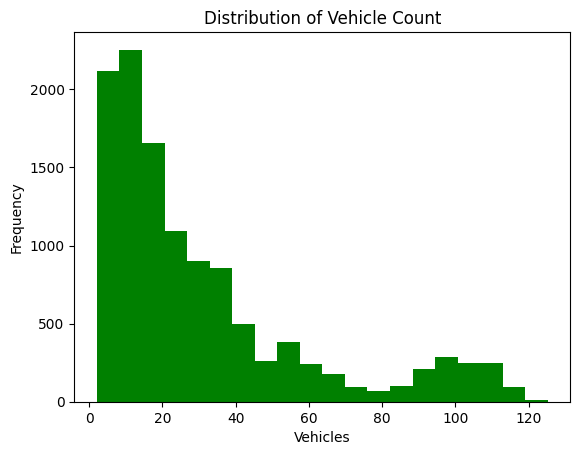

In [ ]:
plt.hist(predictions, bins=20,color="green")
plt.xlabel("Vehicles")
plt.ylabel("Frequency")
plt.title("Distribution of Vehicle Count")
plt.show()